In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import LightSource
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.optimize import linprog

## Génération du terrain

In [22]:
def check_valid_kernel(r, c, radii, centers):
    diffs = centers - c
    dists = np.linalg.norm(diffs, axis=1)
    return np.all(dists >= (r + radii))

def gen_new_kernel(radii, centers, domain, r_range, hcoef_range, max_attempts=1000):
    for _ in range(max_attempts):
        r = np.random.uniform(r_range[0], r_range[1])
        c = np.array([np.random.uniform(domain[0][0], domain[0][1]), np.random.uniform(domain[1][0], domain[1][1])])
        hcoef = np.random.uniform(hcoef_range[0], hcoef_range[1])

        if check_valid_kernel(r, c, radii, centers):
            return r, c, hcoef
    raise RuntimeError("Could not find a valid position after many attempts")

def gen_norm_kernels(n_kernels, domain, r_range, hcoef_range, ex_radii=None, ex_centers=None):
    radii = np.zeros(n_kernels)
    centers = np.zeros((n_kernels, 2))
    height_coeffs = np.zeros(n_kernels)
    for i in range(n_kernels):
        tot_radii = np.concatenate([radii[:i], ex_radii]) if ex_radii is not None else radii[:i]
        tot_centers = np.concatenate([centers[:i], ex_centers]) if ex_centers is not None else centers[:i]
        radii[i], centers[i], height_coeffs[i] = gen_new_kernel(tot_radii, tot_centers, domain, r_range, hcoef_range)
    integral = np.sum(np.pi * radii**2 * height_coeffs / 3)
    heights = height_coeffs / integral
    return radii, centers, heights

def density_kernels(x, radii, heights, centers):
    # Compute distances: (n_obs, n_kernels)
    diffs = x[:, None, :] - centers[None, :, :]
    dists = np.linalg.norm(diffs, axis=2)
    inside = dists <= radii[None, :]
    k_idx = np.argmax(inside, axis=1)
    valid = np.any(inside, axis=1)
    density = np.zeros(len(x))
    
    if np.any(valid):
        valid_idx = np.where(valid)[0]
        k = k_idx[valid_idx]
        d = dists[valid_idx, k]
        r = radii[k]
        h = heights[k]
        density[valid_idx] = h * (1 - (d**2) / (r**2))
    
    return density

domain = [[-4, 4], [-4, 4]]

mu1_r_range = [1.2, 1.6]
mu1_hcoef_range = [1, 3]
mu1_n_kernels = 3
mu1_radii, mu1_centers, mu1_heights = gen_norm_kernels(mu1_n_kernels, domain, mu1_r_range, mu1_hcoef_range)
mu1 = lambda x: density_kernels(x, mu1_radii, mu1_heights, mu1_centers)

mu2_r_range = [0.6, 1.2]
mu2_hcoef_range = [1, 1]
mu2_n_kernels = 5
mu2_radii, mu2_centers, mu2_heights = gen_norm_kernels(mu2_n_kernels, domain, mu2_r_range, mu2_hcoef_range, ex_radii=mu1_radii, ex_centers=mu1_centers)
mu2 = lambda x: density_kernels(x, mu2_radii, mu2_heights, mu2_centers)

In [ ]:
nx_plot = 2000
xmin, xmax = -5, 5
ymin, ymax = -5, 5
x_plot = np.linspace(xmin, xmax, nx_plot)
y_plot = np.linspace(ymin, ymax, nx_plot)
X_plot, Y_plot = np.meshgrid(x_plot, y_plot)

points_plot = np.stack([X_plot.ravel(), Y_plot.ravel()], axis=-1)
Z_mud_plot = mu1(points_plot).reshape(X_plot.shape)
Z_holes_plot = mu2(points_plot).reshape(X_plot.shape)
Z_plot = Z_mud_plot - Z_holes_plot

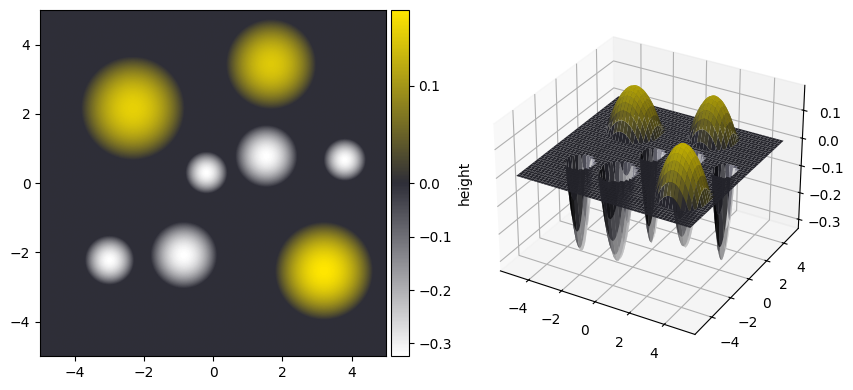

In [170]:
norm_plot = TwoSlopeNorm(vmin=Z_plot.min(), vcenter=0, vmax=Z_plot.max())
colors = [(0.0, "#FFFFFF"), (0.5, "#2E2E38"), (1.0, "#FFE600")]
cmap = LinearSegmentedColormap.from_list("mud_holes_map", colors)
ls = LightSource(azdeg=315, altdeg=45)
rgb = ls.shade(Z_plot, cmap=cmap, norm=norm_plot, vert_exag=1.0, blend_mode='overlay')

fig = plt.figure(figsize=(10,4))

ax1 = fig.add_subplot(1,2,1)
im = ax1.imshow(Z_plot, origin='lower', extent=[xmin, xmax, ymin, ymax], norm=norm_plot, cmap=cmap)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf = ax2.plot_surface(X_plot, Y_plot, Z_plot, facecolors=rgb, linewidth=0, antialiased=True)
ax2.view_init(elev=30, azim=-60)

divider = make_axes_locatable(ax1)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax, label="height")
plt.tight_layout()
plt.subplots_adjust(wspace=-0.2)
plt.savefig("figures/continuous.png", dpi=300)
plt.show()

## Résolution par discrétisation

In [143]:
n = 20
dx = (xmax - xmin) / n
dy = (ymax - ymin) / n
x = xmin + dx/2 + np.arange(n) * dx
y = ymin + dy/2 + np.arange(n) * dy
X, Y = np.meshgrid(x, y)
points = np.stack([X.ravel(), Y.ravel()], axis=-1)
cell_area = dx * dy
a = mu1(points) * cell_area
b = mu2(points) * cell_area
a /= np.sum(a)
b /= np.sum(b)

A = a.reshape((n,n))
B = b.reshape((n,n))
Z = A - B

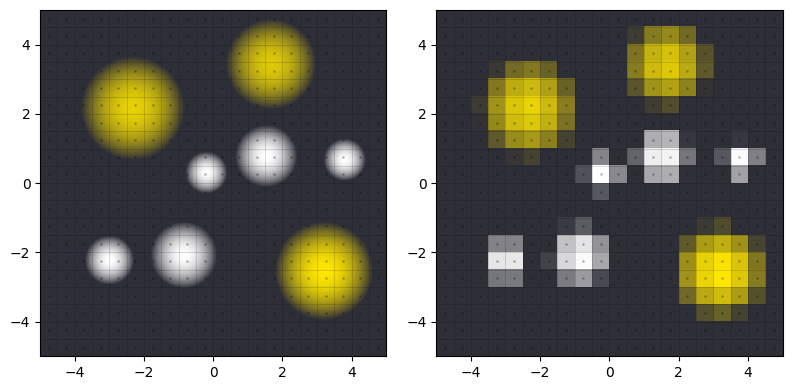

In [171]:
fig, axs = plt.subplots(1, 2, figsize=(10,4))
im0 = axs[0].imshow(Z_plot, origin='lower', extent=[xmin, xmax, ymin, ymax], norm=norm_plot, cmap=cmap)
norm = TwoSlopeNorm(vmin=Z.min(), vcenter=0, vmax=Z.max())
im1 = axs[1].imshow(Z, origin='lower', extent=[xmin, xmax, ymin, ymax], norm=norm, cmap=cmap)
xb = np.linspace(xmin, xmax, n+1)
yb = np.linspace(ymin, ymax, n+1)
Xb, Yb = np.meshgrid(xb, yb)

axs[0].scatter(X, Y, color='black', alpha=0.2, s=1)
axs[1].scatter(X, Y, color='black', alpha=0.2, s=1)

for i in range(n + 1):
    x_line = xmin + i * dx
    axs[0].plot([x_line, x_line], [ymin, ymax], color='black', alpha=0.2, linewidth=0.5)
    axs[1].plot([x_line, x_line], [ymin, ymax], color='black', alpha=0.2, linewidth=0.5)

for j in range(n + 1):
    y_line = ymin + j * dy
    axs[0].plot([xmin, xmax], [y_line, y_line], color='black', alpha=0.2, linewidth=0.5)
    axs[1].plot([xmin, xmax], [y_line, y_line], color='black', alpha=0.2, linewidth=0.5)

plt.tight_layout()
plt.subplots_adjust(wspace=-0.3)
plt.savefig("figures/comparison.png", dpi=300)
plt.show()

In [151]:
C = np.linalg.norm(points[:, None, :] - points[None, :, :], axis=2)**2
c = C.flatten()
A_eq = []
b_eq = []

n2 = len(a)
for i in range(n2):
    row = np.zeros(n2*n2)
    row[i*n2:(i+1)*n2] = 1
    A_eq.append(row)
    b_eq.append(a[i])
for j in range(n2):
    col = np.zeros(n2*n2)
    col[j::n2] = 1
    A_eq.append(col)
    b_eq.append(b[j])

A_eq = np.array(A_eq)
b_eq = np.array(b_eq)
bounds = [(0, None)] * (n2*n2)

res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

pi = res.x.reshape((n2, n2))

print("Erreur marges source:", np.linalg.norm(pi.sum(axis=1) - a))
print("Erreur marges cible:", np.linalg.norm(pi.sum(axis=0) - b))

Erreur marges source: 0.0
Erreur marges cible: 1.821093049291631e-16


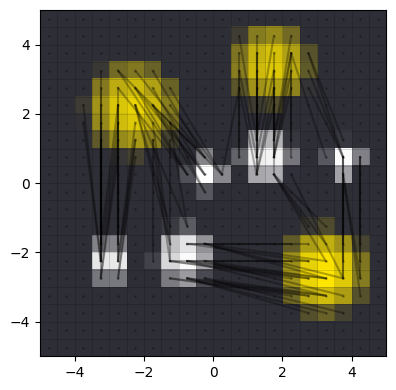

In [172]:
fig, ax = plt.subplots(1, 1, figsize=(5,4))
im1 = ax.imshow(Z, origin='lower', extent=[xmin, xmax, ymin, ymax], norm=norm, cmap=cmap)
ax.scatter(X, Y, color='black', alpha=0.2, s=1)

for i in range(n + 1):
    x_line = xmin + i * dx
    ax.plot([x_line, x_line], [ymin, ymax], color='black', alpha=0.2, linewidth=0.5)

for j in range(n + 1):
    y_line = ymin + j * dy
    ax.plot([xmin, xmax], [y_line, y_line], color='black', alpha=0.2, linewidth=0.5)

threshold = 0

for i in range(n2):
    for j in range(n2):
        if pi[i,j] > threshold:
            ax.plot([points[i,0], points[j,0]], [points[i,1], points[j,1]], 'k-', alpha=0.3)

plt.tight_layout()
plt.savefig("figures/transport.png", dpi=300)
plt.show()